# TextMamba3D — A100 Full Training Pipeline (v4.5)

**Target:** Single A100 40GB (Colab)
**Architecture:** v4.4 SeqCA (unchanged) + **ET-Enriched Text** (v4.5 new)
**Baseline:** v4.4 Mean Dice delta = +0.55% (first positive text guidance)
**Goal:** Fix ET regression (-0.16%) via ET-specific text enrichment

v4.5 changes vs v4.4:
- **ET-Enriched Text**: Auto-extract enhancement features from T1ce images (NOT GT masks)
- **LaCLIP Stochastic Selection**: 50% original text / 50% enriched during training
- **max_text_len 128->192**: Accommodate concatenated text
- **No architecture change** — same SeqCA at stages 1,2,3
- **No new losses** — same Dice+CE+Edge

**Key insight:** v4.4 ET regressed because text lacks ET-specific semantics.
T1ce intensity thresholding can detect enhancing regions without information leakage.

**Zero annotation cost** — features extracted from T1ce image, not GT mask.

In [1]:
# Mount Google Drive (run in Colab web UI if using VS Code plugin)
from google.colab import drive
drive.mount('/content/drive')

# Install packages (cached on Drive)
!nvidia-smi 2>/dev/null || echo "No GPU detected (CPU mode)"
!pip install -q --cache-dir=/content/drive/MyDrive/pip_cache mamba-ssm causal-conv1d transformers nibabel tensorboard pyyaml tqdm

Mounted at /content/drive
Tue Mar 17 11:08:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+---------------------

In [2]:
import os, zipfile, shutil

REPO_DIR = '/content/TextMamba3D'
DRIVE_BASE = '/content/drive/MyDrive/TextMamba3D'
DRIVE_CODE_ZIP = os.path.join(DRIVE_BASE, 'TextMamba3D_code.zip')
DRIVE_CODE_DIR = os.path.join(DRIVE_BASE, 'TextMamba3D_code')

# 获取代码：VS Code 插件同步 → Drive zip → Drive 文件夹
tm_file = os.path.join(REPO_DIR, 'models/textmamba3d.py')
if os.path.exists(tm_file):
    print(f'Local code available at {REPO_DIR} (VS Code plugin)')
elif os.path.exists(DRIVE_CODE_ZIP):
    print(f'Extracting code from {DRIVE_CODE_ZIP}...')
    os.makedirs(REPO_DIR, exist_ok=True)
    with zipfile.ZipFile(DRIVE_CODE_ZIP, 'r') as zf:
        zf.extractall(REPO_DIR)
    print(f'Extracted to {REPO_DIR}')
elif os.path.exists(DRIVE_CODE_DIR):
    print(f'Copying code from {DRIVE_CODE_DIR}...')
    shutil.copytree(DRIVE_CODE_DIR, REPO_DIR)
    print(f'Copied to {REPO_DIR}')
else:
    raise FileNotFoundError(
        f'Code not found. Please either:\n'
        f'  1. Use VS Code Colab plugin to sync local project\n'
        f'  2. Upload TextMamba3D_code.zip to {DRIVE_BASE} on Google Drive'
    )

os.chdir(REPO_DIR)
print(f'Working directory: {os.getcwd()}')

# Extract BraTS data from Drive
DATA_ZIP = os.path.join(DRIVE_BASE, "TextBraTS_data.zip")
DATA_DIR = os.path.join(REPO_DIR, "data/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

if not os.path.exists(DATA_DIR):
    os.makedirs(os.path.dirname(DATA_DIR), exist_ok=True)
    if os.path.exists(DATA_ZIP):
        print(f"Extracting {DATA_ZIP}...")
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(os.path.dirname(DATA_DIR))
        if os.path.exists(DATA_DIR):
            print(f"Data extracted. Cases: {len(os.listdir(DATA_DIR))}")
        else:
            print(f"ERROR: Expected path not found after extraction: {DATA_DIR}")
            print("Actual contents:", os.listdir(os.path.dirname(DATA_DIR)))
    else:
        print(f"ERROR: {DATA_ZIP} not found on Drive")
else:
    print(f"Data already exists. Cases: {len(os.listdir(DATA_DIR))}")

# Count samples
if os.path.exists(DATA_DIR):
    cases = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
    print(f"Total BraTS cases: {len(cases)}")

Extracting code from /content/drive/MyDrive/TextMamba3D/TextMamba3D_code.zip...
Extracted to /content/TextMamba3D
Working directory: /content/TextMamba3D
Extracting /content/drive/MyDrive/TextMamba3D/TextBraTS_data.zip...
Data extracted. Cases: 371
Total BraTS cases: 369


## 3. Code Patches

**V4.4 patches (architecture, unchanged):**
1. `models/fusion.py` — append SequentialCrossAttention + MultiScaleSeqCA
2. `models/textmamba3d.py` — swap import to use MultiScaleSeqCA

**V4.5 patches (new):**
3. `data/brats_textbrats_dataset.py` — add ET-enriched stochastic selection
4. `configs/textbrats_v7.yaml` — new config with et_enriched=true

In [3]:
import pathlib

# [v4.4-1] Append Sequential Cross-Attention classes to models/fusion.py
fusion_path = pathlib.Path('models/fusion.py')
content = fusion_path.read_text(encoding='utf-8')

if 'SequentialCrossAttention' in content:
    print("[v4.4-1] SeqCA already exists in fusion.py, skipping")
else:
    NL = chr(10)
    seqca_code = NL.join([
        "",
        "",
        "# ---------------------------------------------------------------------------",
        "# Sequential Cross-Attention (TextBraTS-inspired, MICCAI 2025)",
        "# ---------------------------------------------------------------------------",
        "",
        "class SequentialCrossAttention(nn.Module):",
        "    \"\"\"TextBraTS-style Sequential Cross-Attention for text-guided segmentation.",
        "",
        "    Two-step cross-attention that reverses the Q/KV direction:",
        "      Step 1 (T2I): Text=Q, Image=KV -> refined features (text-length)",
        "      Step 2 (I2T): Image=Q, Refined=KV -> joint features (image-length)",
        "",
        "    This ensures text actively \"asks\" the image where its descriptions are",
        "    relevant, rather than the image passively querying text tokens.",
        "    \"\"\"",
        "",
        "    def __init__(self, feat_dim: int, text_dim: int, num_heads: int = 4):",
        "        super().__init__()",
        "        assert feat_dim % num_heads == 0, \\",
        "            f\"feat_dim ({feat_dim}) must be divisible by num_heads ({num_heads})\"",
        "        self.num_heads = num_heads",
        "        self.head_dim = feat_dim // num_heads",
        "        self.scale = self.head_dim ** -0.5",
        "",
        "        # Project text to image feature dimension",
        "        self.text_proj = nn.Sequential(",
        "            nn.Linear(text_dim, feat_dim),",
        "            nn.LayerNorm(feat_dim),",
        "        )",
        "",
        "        # Step 1: Text queries Image (T2I)",
        "        self.t2i_norm_q = nn.LayerNorm(feat_dim)",
        "        self.t2i_norm_kv = nn.LayerNorm(feat_dim)",
        "        self.t2i_q = nn.Linear(feat_dim, feat_dim)",
        "        self.t2i_k = nn.Linear(feat_dim, feat_dim)",
        "        self.t2i_v = nn.Linear(feat_dim, feat_dim)",
        "        self.t2i_out = nn.Sequential(",
        "            nn.Linear(feat_dim, feat_dim),",
        "            nn.LayerNorm(feat_dim),",
        "        )",
        "",
        "        # Step 2: Image queries Refined (I2T)",
        "        self.i2t_norm_q = nn.LayerNorm(feat_dim)",
        "        self.i2t_norm_kv = nn.LayerNorm(feat_dim)",
        "        self.i2t_q = nn.Linear(feat_dim, feat_dim)",
        "        self.i2t_k = nn.Linear(feat_dim, feat_dim)",
        "        self.i2t_v = nn.Linear(feat_dim, feat_dim)",
        "        self.i2t_out = nn.Linear(feat_dim, feat_dim)",
        "",
        "        # Zero-init Step 2 output for identity-preserving start",
        "        nn.init.zeros_(self.i2t_out.weight)",
        "        nn.init.zeros_(self.i2t_out.bias)",
        "",
        "    def _multi_head_attn(",
        "        self,",
        "        q: torch.Tensor,",
        "        k: torch.Tensor,",
        "        v: torch.Tensor,",
        "        mask: torch.Tensor | None = None,",
        "    ) -> torch.Tensor:",
        "        \"\"\"Multi-head attention computation.\"\"\"",
        "        B, Nq, D = q.shape",
        "        H, hd = self.num_heads, self.head_dim",
        "",
        "        q = q.reshape(B, Nq, H, hd).transpose(1, 2)",
        "        k = k.reshape(B, -1, H, hd).transpose(1, 2)",
        "        v = v.reshape(B, -1, H, hd).transpose(1, 2)",
        "",
        "        attn = (q @ k.transpose(-2, -1)) * self.scale",
        "",
        "        if mask is not None:",
        "            attn = attn.masked_fill(",
        "                mask.unsqueeze(1).unsqueeze(2) == 0,",
        "                float('-inf'),",
        "            )",
        "",
        "        attn = attn.softmax(dim=-1)",
        "        attn = torch.nan_to_num(attn)",
        "",
        "        out = (attn @ v).transpose(1, 2).reshape(B, Nq, D)",
        "        return out",
        "",
        "    def forward(",
        "        self,",
        "        x: torch.Tensor,",
        "        text_feat: torch.Tensor,",
        "        text_mask: torch.Tensor | None = None,",
        "    ) -> torch.Tensor:",
        "        \"\"\"Forward: x=[B,N,D] image, text_feat=[B,M,D_text] -> [B,N,D].\"\"\"",
        "        residual = x",
        "",
        "        # Project text to image feature space",
        "        text_proj = self.text_proj(text_feat)",
        "",
        "        # Step 1: Text=Q, Image=KV",
        "        q1 = self.t2i_q(self.t2i_norm_q(text_proj))",
        "        k1 = self.t2i_k(self.t2i_norm_kv(x))",
        "        v1 = self.t2i_v(self.t2i_norm_kv(x))",
        "        refined = self.t2i_out(self._multi_head_attn(q1, k1, v1))",
        "",
        "        # Step 2: Image=Q, Refined=KV",
        "        q2 = self.i2t_q(self.i2t_norm_q(x))",
        "        k2 = self.i2t_k(self.i2t_norm_kv(refined))",
        "        v2 = self.i2t_v(self.i2t_norm_kv(refined))",
        "        joint = self.i2t_out(self._multi_head_attn(q2, k2, v2, text_mask))",
        "",
        "        return residual + joint",
        "",
        "",
        "class MultiScaleSeqCA(nn.Module):",
        "    \"\"\"Apply Sequential Cross-Attention at multiple encoder scales.\"\"\"",
        "",
        "    def __init__(self, stage_dims: list[int], text_dim: int, num_heads: int = 4):",
        "        super().__init__()",
        "        self.attn_layers = nn.ModuleList([",
        "            SequentialCrossAttention(dim, text_dim, num_heads=num_heads)",
        "            for dim in stage_dims",
        "        ])",
        "",
        "    def forward(",
        "        self,",
        "        features: list[torch.Tensor],",
        "        text_feat: torch.Tensor,",
        "        text_mask: torch.Tensor | None = None,",
        "    ) -> list[torch.Tensor]:",
        "        return [",
        "            attn(feat, text_feat, text_mask)",
        "            for attn, feat in zip(self.attn_layers, features)",
        "        ]",
    ])
    fusion_path.write_text(content + NL + seqca_code + NL, encoding='utf-8')
    print("[v4.4-1] Appended SequentialCrossAttention + MultiScaleSeqCA to fusion.py")
    print(f"  fusion.py is now {len((content + seqca_code).splitlines())} lines")

[v4.4-1] SeqCA already exists in fusion.py, skipping


In [4]:
import os, pathlib, shutil

# [v4.4-2] Overwrite textmamba3d.py with V4.4 version (MultiScaleSeqCA)
# Self-contained: uses absolute path, does not depend on Cell 2's os.chdir
REPO_DIR = '/content/TextMamba3D'
tm_path = pathlib.Path(REPO_DIR) / 'models' / 'textmamba3d.py'

NL = chr(10)
tm_content = NL.join([
    "# models/textmamba3d.py",
    '"""Text-guided 3D medical image segmentation with Mamba architecture."""',
    "",
    "from typing import Optional",
    "",
    "import torch",
    "import torch.nn as nn",
    "",
    "from .decoder_3d import MambaDecoder3D",
    "from .encoder_3d import MambaEncoder3D",
    "from .fusion import MultiScaleSeqCA",
    "from .text_encoder import TextMambaEncoder",
    "",
    "",
    "class TextMamba3D(nn.Module):",
    '    """Text-guided 3D medical image segmentation model using Mamba architecture."""',
    "",
    "    def __init__(",
    "        self,",
    "        img_size: tuple[int, int, int] = (96, 96, 96),",
    "        in_channels: int = 4,",
    "        out_channels: int = 4,",
    "        embed_dim: int = 96,",
    "        depths: list[int] = [2, 2, 2, 2],",
    "        patch_size: tuple[int, int, int] = (4, 4, 4),",
    "        text_embed_dim: int = 256,",
    "        text_max_len: int = 256,",
    "        text_depth: int = 4,",
    "        d_state: int = 16,",
    "        dropout: float = 0.0,",
    "        use_pretrained_text: bool = True,",
    "        unfreeze_text_layers: int = 0,",
    "        use_checkpoint: bool = False,",
    "        text_model_path: str | None = None,",
    "        deep_supervision: bool = False,",
    "    ) -> None:",
    "        super().__init__()",
    "",
    "        self.text_embed_dim = text_embed_dim",
    "        self.text_max_len = text_max_len",
    "        bottleneck_dim = embed_dim * (2 ** (len(depths) - 1))",
    "",
    "        self.img_encoder = MambaEncoder3D(",
    "            img_size=img_size,",
    "            in_channels=in_channels,",
    "            embed_dim=embed_dim,",
    "            depths=depths,",
    "            patch_size=patch_size,",
    "            d_state=d_state,",
    "            dropout=dropout,",
    "            use_checkpoint=use_checkpoint,",
    "        )",
    "",
    "        self.text_encoder = TextMambaEncoder(",
    "            embed_dim=text_embed_dim,",
    "            max_len=text_max_len,",
    "            depth=text_depth,",
    "            d_state=d_state,",
    "            dropout=dropout,",
    "            use_pretrained=use_pretrained_text,",
    "            unfreeze_last_n=unfreeze_text_layers,",
    "            model_path=text_model_path,",
    "        )",
    "",
    "        # Multi-scale cross-attention: text guides skip connections at stages 1,2,3",
    "        # Stage 0 excluded (32K tokens too expensive for cross-attention)",
    "        stage_dims = [embed_dim * (2 ** i) for i in range(1, len(depths))]",
    "        self.multi_scale_attn = MultiScaleSeqCA(",
    "            stage_dims=stage_dims,     # [96, 192, 384] for embed_dim=48",
    "            text_dim=text_embed_dim,   # 256",
    "            num_heads=4,               # head_dim varies per stage",
    "        )",
    "",
    "        self.decoder = MambaDecoder3D(",
    "            img_size=img_size,",
    "            patch_size=patch_size,",
    "            out_channels=out_channels,",
    "            embed_dim=embed_dim,",
    "            depths=depths,",
    "            d_state=d_state,",
    "            dropout=dropout,",
    "            use_checkpoint=use_checkpoint,",
    "            deep_supervision=deep_supervision,",
    "        )",
    "",
    "        self.img_proj = nn.Sequential(",
    "            nn.Linear(bottleneck_dim, text_embed_dim),",
    "            nn.LayerNorm(text_embed_dim),",
    "        )",
    "",
    "    def forward(",
    "        self,",
    "        img: torch.Tensor,",
    "        text_ids: Optional[torch.Tensor] = None,",
    "        attention_mask: Optional[torch.Tensor] = None,",
    "        return_features: bool = False,",
    "        use_text: bool = True,",
    "    ) -> torch.Tensor | tuple[",
    "        torch.Tensor,",
    "        Optional[torch.Tensor],",
    "        Optional[torch.Tensor],",
    "        Optional[torch.Tensor],",
    "    ]:",
    '        """Forward pass for text-guided 3D segmentation."""',
    "        img_features = self.img_encoder(img)",
    "",
    "        has_text = use_text and text_ids is not None",
    "        if has_text:",
    "            text_features = self.text_encoder(text_ids, attention_mask)",
    "            # Multi-scale fusion: stages 1,2,3 get text cross-attention",
    "            # Stage 0 stays raw (32K tokens, too expensive for cross-attention)",
    "            fused = self.multi_scale_attn(",
    "                img_features[1:], text_features, attention_mask",
    "            )",
    "            decoder_features = [img_features[0]] + fused",
    "        else:",
    "            # Bypass fusion entirely for text-free path",
    "            decoder_features = img_features",
    "",
    "        seg_output = self.decoder(decoder_features)",
    "",
    "        if not return_features:",
    "            return seg_output",
    "",
    "        if has_text:",
    "            # Contrastive: project fused bottleneck for alignment",
    "            pixel_feat = decoder_features[-1]",
    "            img_global = self.img_proj(pixel_feat.mean(dim=1))",
    "            text_global = self.text_encoder.get_global_feature(text_features)",
    "            return seg_output, img_global, text_global, pixel_feat",
    "        else:",
    "            return seg_output, None, None, None",
    "",
    "    def forward_without_text(self, img: torch.Tensor) -> torch.Tensor:",
    '        """Convenience method for inference without text guidance."""',
    "        return self.forward(img, text_ids=None, use_text=False)",
    "",
])

tm_path.write_text(tm_content, encoding='utf-8')

# Clear __pycache__ to force Python to reload from .py
cache_dir = pathlib.Path(REPO_DIR) / 'models' / '__pycache__'
if cache_dir.exists():
    shutil.rmtree(cache_dir)
    print("[v4.4-2] Cleared models/__pycache__")

# Verify: read back and check critical lines
written = tm_path.read_text(encoding='utf-8')
assert 'MultiScaleSeqCA' in written, "FAIL: MultiScaleSeqCA not found in written file"
assert 'img_dim' not in written, "FAIL: old 'img_dim' kwarg still present"
assert 'MambaFusion' not in written, "FAIL: old MambaFusion reference still present"
assert 'self.multi_scale_attn' in written, "FAIL: self.multi_scale_attn not found"
print(f"[v4.4-2] Wrote {tm_path} ({len(written.splitlines())} lines)")
print(f"  Path: {tm_path.resolve()}")
print("  Verified: MultiScaleSeqCA, no img_dim, no MambaFusion, self.multi_scale_attn")
print("  OK — ready for smoke test")

[v4.4-2] Wrote /content/TextMamba3D/models/textmamba3d.py (136 lines)
  Path: /content/TextMamba3D/models/textmamba3d.py
  Verified: MultiScaleSeqCA, no img_dim, no MambaFusion, self.multi_scale_attn
  OK — ready for smoke test


In [5]:
import pathlib, shutil

# [v4.5-1] Patch brats_textbrats_dataset.py: add ET-enriched stochastic selection
# Only patches TextBraTSDataset class (train.py instantiates it directly)
ds_path = pathlib.Path('data/brats_textbrats_dataset.py')
ds_content = ds_path.read_text(encoding='utf-8')

if 'et_enriched' in ds_content:
    print("[v4.5-1] ET-enriched patch already applied, skipping")
else:
    NL = chr(10)
    # Add params to __init__
    ds_content = ds_content.replace(
        "        seed: int = 42," + NL + "    ):",
        "        seed: int = 42," + NL +
        "        et_enriched: bool = False," + NL +
        "        enriched_prob: float = 0.5," + NL +
        "    ):"
    )
    # Store new attributes
    ds_content = ds_content.replace(
        "        self.use_text_features = use_text_features" + NL,
        "        self.use_text_features = use_text_features" + NL +
        "        self.et_enriched = et_enriched" + NL +
        "        self.enriched_prob = enriched_prob" + NL
    )
    # Add _load_enriched_text method
    method = (NL +
        '    def _load_enriched_text(self, case_dir, case_name):' + NL +
        '        path = os.path.join(case_dir, f"{case_name}_et_enriched.txt")' + NL +
        '        if os.path.exists(path):' + NL +
        "            with open(path, 'r', encoding='utf-8') as f:" + NL +
        '                return f.read().strip()' + NL +
        '        return None' + NL + NL
    )
    ds_content = ds_content.replace(
        "    def _load_text_features(",
        method + "    def _load_text_features("
    )
    # Replace text loading with stochastic selection
    old_text_load = (
        "        # Load expert text (NO information leakage!)" + NL +
        "        text = self._load_text(case_dir, case_name)"
    )
    new_text_load = (
        "        # Load expert text (NO information leakage!)" + NL +
        "        original_text = self._load_text(case_dir, case_name)" + NL +
        NL +
        "        # LaCLIP stochastic selection" + NL +
        "        if self.et_enriched:" + NL +
        "            enriched = self._load_enriched_text(case_dir, case_name)" + NL +
        "            if self.split == 'train':" + NL +
        "                if enriched and np.random.random() < self.enriched_prob:" + NL +
        "                    text = original_text + ' ' + enriched" + NL +
        "                else:" + NL +
        "                    text = original_text" + NL +
        "            else:" + NL +
        "                text = (original_text + ' ' + enriched) if enriched else original_text" + NL +
        "        else:" + NL +
        "            text = original_text"
    )
    ds_content = ds_content.replace(old_text_load, new_text_load)
    ds_path.write_text(ds_content, encoding='utf-8')
    print("[v4.5-1] Patched brats_textbrats_dataset.py (TextBraTSDataset class)")
    print(f"  {len(ds_content.splitlines())} lines")

# Clear data __pycache__
cache = pathlib.Path('data/__pycache__')
if cache.exists():
    shutil.rmtree(cache)

# Verify
v = ds_path.read_text(encoding='utf-8')
assert 'et_enriched' in v and '_load_enriched_text' in v
print("  Verified: et_enriched + _load_enriched_text present")

[v4.5-1] ET-enriched patch already applied, skipping
  Verified: et_enriched + _load_enriched_text present


In [6]:
import pathlib, yaml

# [v4.5-2] Create configs/textbrats_v7.yaml
config = {
    'data': {
        'data_dir': './data/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData',
        'dataset_type': 'textbrats',
        'patch_size': [128, 128, 128],
        'batch_size': 4,
        'num_workers': 4,
        'train_ratio': 0.596,
        'val_ratio': 0.149,
        'et_enriched': True,
        'enriched_prob': 0.5,
    },
    'model': {
        'img_size': [128, 128, 128],
        'in_channels': 4, 'out_channels': 4,
        'embed_dim': 48, 'depths': [2, 2, 2, 2],
        'dropout': 0.1, 'text_embed_dim': 256, 'text_max_len': 192,
        'use_pretrained_text': True, 'unfreeze_text_layers': 2,
        'text_model_path': None,
    },
    'loss': {
        'dice_weight': 1.0, 'ce_weight': 1.0, 'edge_weight': 1.0,
        'contrastive_weight': 0.05, 'temperature': 0.07,
        'class_weights': [0.25, 3.0, 1.0, 4.0],
    },
    'augmentation': {'use_elastic': True, 'use_modality_dropout': True},
    'training': {
        'epochs': 200, 'lr': 0.0001, 'weight_decay': 0.01,
        'warmup_epochs': 10, 'contrastive_warmup_epochs': 30,
        'patience': 40, 'gradient_accumulation': 1,
        'gradient_checkpointing': True, 'deep_supervision': True,
        'ds_weights': [0.2, 0.1, 0.05], 'use_amp': True,
        'no_text_ratio': 0.15, 'gradient_clip_norm': 1.0,
    },
    'eval': {
        'metrics': ['dice', 'hd95'],
        'sliding_window': True, 'sw_overlap': 0.5, 'sw_batch_size': 2,
    },
    'experiment': {
        'name': 'TextMamba3D_A100_v4.5_et_enriched',
        'description': 'V4.5: SeqCA + ET-Enriched Text + LaCLIP stochastic selection (p=0.5)',
    },
}

pathlib.Path('configs').mkdir(exist_ok=True)
NL = chr(10)
with open('configs/textbrats_v7.yaml', 'w') as f:
    f.write('# textbrats_v7.yaml - V4.5 ET-Enriched Text + LaCLIP' + NL)
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print("[v4.5-2] Created configs/textbrats_v7.yaml")
print("  model.text_max_len = 192 (v4.4 was 128, increased for concatenated text)")
print("All V4.5 patches applied!")

[v4.5-2] Created configs/textbrats_v7.yaml
  model.text_max_len = 192 (v4.4 was 128, increased for concatenated text)
All V4.5 patches applied!


## 4. ET-Enriched Text Preprocessing

Extract enhancement features from **T1ce images** (NOT GT masks) for all BraTS cases.
Generates `{case_name}_et_enriched.txt` alongside existing data.

**No information leakage:** Features from T1ce intensity analysis (mean + 2*std),
mimicking how radiologists identify enhancing tumor on contrast-enhanced T1.

In [7]:
import os, sys
os.chdir(REPO_DIR)

DATA_DIR = "./data/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

# Check if already generated
sample_case = sorted(d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d)))[0]
sample_enriched = os.path.join(DATA_DIR, sample_case, f"{sample_case}_et_enriched.txt")

if os.path.exists(sample_enriched):
    count = sum(
        1 for d in os.listdir(DATA_DIR)
        if os.path.isdir(os.path.join(DATA_DIR, d))
        and os.path.exists(os.path.join(DATA_DIR, d, f"{d}_et_enriched.txt"))
    )
    print(f"ET-enriched text already generated for {count} cases, skipping")
    for case in sorted(os.listdir(DATA_DIR))[:3]:
        path = os.path.join(DATA_DIR, case, f"{case}_et_enriched.txt")
        if os.path.exists(path):
            with open(path, 'r') as f:
                print(f"  {case}: {f.read().strip()[:120]}...")
else:
    print("Generating ET-enriched text descriptions from T1ce images...")
    sys.path.insert(0, '.')
    from data.et_text_enrichment import process_all_cases
    results = process_all_cases(DATA_DIR)

    no_enhancement = sum(1 for desc in results.values() if "No significant" in desc)
    total = len(results)
    print(f"Total: {total}, No enhancement: {no_enhancement} ({no_enhancement/total*100:.1f}%)")
    print()
    for name, desc in list(results.items())[:5]:
        print(f"  {name}: {desc}")

Generating ET-enriched text descriptions from T1ce images...
  Processed 50/369
  Processed 100/369
  Processed 150/369
  Processed 200/369
  Processed 250/369
  Processed 300/369
  Processed 350/369
  Processed 369/369
Generated ET descriptions for 369 cases
Total: 369, No enhancement: 0 (0.0%)

  BraTS20_Training_001: Solid enhancing lesion on T1ce, in the right anterior inferior region, with irregular margins, showing moderate enhancement, with multifocal enhancing components.
  BraTS20_Training_002: Solid enhancing lesion on T1ce, in the left anterior inferior region, with irregular margins, showing moderate enhancement, with multifocal enhancing components.
  BraTS20_Training_003: Solid enhancing lesion on T1ce, in the left anterior inferior region, with irregular margins, showing focal enhancement, with multifocal enhancing components.
  BraTS20_Training_004: Solid enhancing lesion on T1ce, in the left anterior inferior region, with irregular margins, showing moderate enhancement

## 5. Smoke Test

Quick architecture check: 10 samples, 2 epochs.
Verifies stochastic selection + SeqCA dimensions are correct and no OOM.

In [8]:
# Smoke test: 10 samples, 2 epochs, vision-only (fastest check)
!python train.py --config configs/textbrats_v7.yaml --max-samples 10 --no-text-ratio 1.0 --grad-accum 1 --max-epochs 2

!nvidia-smi --query-gpu=memory.used --format=csv,noheader,nounits 2>/dev/null || echo "No GPU detected (CPU mode)"
print("(Peak VRAM after vision-only smoke test)")

2026-03-17 11:19:20.632794: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 11:19:20.658654: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773746360.691918    7744 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773746360.699987    7744 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773746360.718832    7744 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [9]:
# Smoke test with text guidance: verify enriched text + SeqCA fusion works
!python train.py --config configs/textbrats_v7.yaml --max-samples 10 --no-text-ratio 0.0 --grad-accum 1 --max-epochs 2

!nvidia-smi --query-gpu=memory.used --format=csv,noheader,nounits 2>/dev/null || echo "No GPU detected (CPU mode)"
print("(Peak VRAM after text-guided smoke test -- should be slightly higher)")

2026-03-17 11:21:07.088795: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 11:21:07.106804: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773746467.128677    8635 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773746467.135900    8635 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773746467.154468    8635 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 6. Training

V4.5 uses the same train.py as v4.4. Only the text input changes:
- 50% of training steps use enriched text (original + ET description)
- 50% use original text only (LaCLIP stochastic selection)
- Validation/test always use enriched text
- max_text_len increased to 192 for concatenated text

In [10]:
import os, shutil, glob

DRIVE_CKPT = os.path.join(DRIVE_BASE, "checkpoints")
os.makedirs(DRIVE_CKPT, exist_ok=True)

def sync_checkpoints_to_drive():
    local_ckpt = os.path.join(REPO_DIR, "checkpoints")
    if not os.path.exists(local_ckpt):
        return
    for f in glob.glob(os.path.join(local_ckpt, "*.pth")):
        dst = os.path.join(DRIVE_CKPT, os.path.basename(f))
        shutil.copy2(f, dst)
    print(f"Synced checkpoints to {DRIVE_CKPT}")

# Clean local checkpoints (fresh start for v4.5)
for f in glob.glob(os.path.join(REPO_DIR, "checkpoints/*.pth")):
    os.remove(f)
print("Cleaned local checkpoints for v4.5 fresh start")
print("(v4.4 best preserved on Drive as best_v4.4.pth)")

Cleaned local checkpoints for v4.5 fresh start
(v4.4 best preserved on Drive as best_v4.4.pth)


In [11]:
os.chdir(REPO_DIR)
os.environ["DRIVE_CKPT_DIR"] = DRIVE_CKPT

# V4.5 training: SeqCA + ET-Enriched Text + LaCLIP stochastic selection
!python -u train.py \
    --config configs/textbrats_v7.yaml \
    --no-text-ratio 0.15 \
    --grad-accum 1 \
    2>&1 | tee training_v4.5.log | grep --line-buffered -E "(Epoch [0-9]+:|train_loss=|Best |Error|Traceback)"

# Sync and save
sync_checkpoints_to_drive()

best_ckpt = os.path.join(DRIVE_CKPT, "best_v4.5.pth")
local_best = os.path.join(REPO_DIR, "checkpoints/best.pth")
if os.path.exists(local_best):
    shutil.copy2(local_best, best_ckpt)
    print(f"Best checkpoint saved: {best_ckpt}")

Epoch 0: 100%|██████████| 55/55 [01:14<00:00,  1.36s/it, loss=2.9887, text=Y]
Epoch 0: NaN/Inf skipped batches=0
Epoch 0: train_loss=3.0451
Epoch 1: 100%|██████████| 55/55 [01:10<00:00,  1.29s/it, loss=2.7937, text=Y]
Epoch 1: NaN/Inf skipped batches=0
Epoch 1: train_loss=2.8672
Epoch 2: 100%|██████████| 55/55 [01:10<00:00,  1.29s/it, loss=2.5590, text=Y]
Epoch 2: NaN/Inf skipped batches=0
Epoch 2: train_loss=2.6777
Epoch 3: 100%|██████████| 55/55 [01:08<00:00,  1.25s/it, loss=2.2240, text=Y]
Epoch 3: NaN/Inf skipped batches=0
Epoch 3: train_loss=2.3043
Epoch 4: 100%|██████████| 55/55 [01:07<00:00,  1.22s/it, loss=1.9075, text=Y]
Epoch 4: NaN/Inf skipped batches=0
Epoch 4: train_loss=1.8071
Epoch 5: 100%|██████████| 55/55 [01:08<00:00,  1.25s/it, loss=1.6043, text=Y]
Epoch 5: NaN/Inf skipped batches=0
Epoch 5: train_loss=1.6449
Epoch 6: 100%|██████████| 55/55 [01:10<00:00,  1.28s/it, loss=1.5263, text=Y]
Epoch 6: NaN/Inf skipped batches=0
Epoch 6: train_loss=1.6161
Epoch 7: 100%|██████

## 7. Full-Volume Evaluation (Sliding Window)

Compare with-text vs without-text on test set (94 cases).
Key metrics: per-region Dice (ET, WT, TC) and HD95.
**Success criterion:** ET delta turns positive (currently -0.16% in v4.4).

In [12]:
os.chdir(REPO_DIR)

ckpt = os.path.join(REPO_DIR, "checkpoints/best.pth")
if not os.path.exists(ckpt):
    ckpt = os.path.join(DRIVE_CKPT, "best_v4.5.pth")

if os.path.exists(ckpt):
    print("=" * 60)
    print("Evaluation: With Text (SeqCA + ET-Enriched)")
    print("=" * 60)
    !python evaluate_full.py \
        --config configs/textbrats_v7.yaml \
        --checkpoint "{ckpt}" \
        --split test \
        --use-text \
        --overlap 0.5

    print()

    print("=" * 60)
    print("Evaluation: Without Text (fusion bypassed)")
    print("=" * 60)
    !python evaluate_full.py \
        --config configs/textbrats_v7.yaml \
        --checkpoint "{ckpt}" \
        --split test \
        --no-text \
        --overlap 0.5

    print()
    print("=" * 60)
    print("Compare: with-text Dice - without-text Dice = text guidance delta")
    print("V4.4 baseline: mean +0.55%, ET -0.16%, TC +1.05%, WT +0.74%")
    print("V4.5 target: ET delta turns POSITIVE")
    print("=" * 60)
else:
    print(f"No checkpoint found at {ckpt}")
    print("Run training first")

Evaluation: With Text (SeqCA + ET-Enriched)
Loading weights: 100% 199/199 [00:00<00:00, 1069.94it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from d

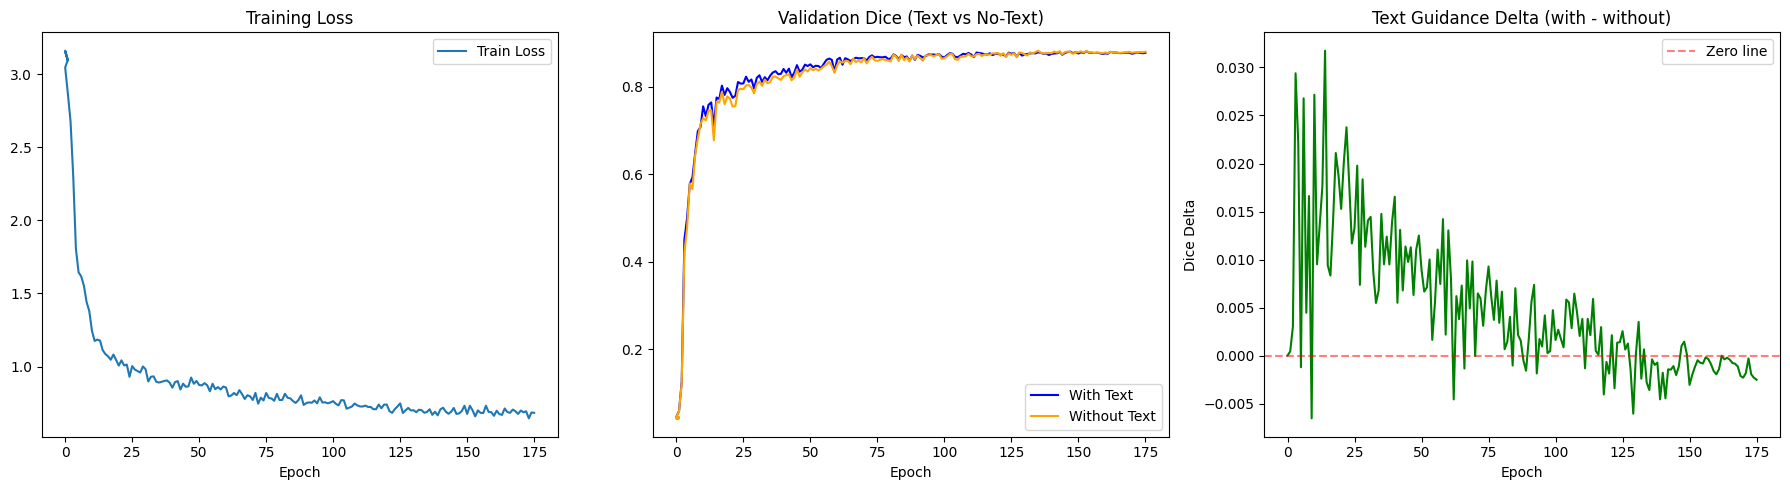

Saved: v4.5_training_curves.png


In [13]:
import matplotlib.pyplot as plt

try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    ea = EventAccumulator('logs')
    ea.Reload()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    if 'Loss/train' in ea.Tags()['scalars']:
        steps = [s.step for s in ea.Scalars('Loss/train')]
        values = [s.value for s in ea.Scalars('Loss/train')]
        axes[0].plot(steps, values, label='Train Loss')
        axes[0].set_title('Training Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].legend()

    for tag, label, color in [
        ('Dice/val', 'With Text', 'blue'),
        ('Dice/val_no_text', 'Without Text', 'orange'),
    ]:
        if tag in ea.Tags()['scalars']:
            steps = [s.step for s in ea.Scalars(tag)]
            values = [s.value for s in ea.Scalars(tag)]
            axes[1].plot(steps, values, label=label, color=color)
    axes[1].set_title('Validation Dice (Text vs No-Text)')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    if 'Dice/val' in ea.Tags()['scalars'] and 'Dice/val_no_text' in ea.Tags()['scalars']:
        wt = {s.step: s.value for s in ea.Scalars('Dice/val')}
        nt = {s.step: s.value for s in ea.Scalars('Dice/val_no_text')}
        common = sorted(set(wt) & set(nt))
        deltas = [wt[e] - nt[e] for e in common]
        axes[2].plot(common, deltas, color='green')
        axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Zero line')
        axes[2].set_title('Text Guidance Delta (with - without)')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Dice Delta')
        axes[2].legend()

    plt.tight_layout()
    plt.savefig('v4.5_training_curves.png', dpi=150)
    plt.show()
    print("Saved: v4.5_training_curves.png")

except Exception as e:
    print(f"Could not plot: {e}")
    print("TensorBoard logs may not exist yet.")

## 8. Resume Training (After Colab Disconnect)

Run this cell to resume from the last checkpoint saved on Drive.

In [14]:
import os, shutil
os.chdir(REPO_DIR)
os.environ["DRIVE_CKPT_DIR"] = DRIVE_CKPT

resume_ckpt = os.path.join(DRIVE_CKPT, "last.pth")
if os.path.exists(resume_ckpt):
    print(f"Resuming from {resume_ckpt}")
    !python train.py \
        --config configs/textbrats_v7.yaml \
        --resume "{resume_ckpt}" \
        --no-text-ratio 0.15 \
        --grad-accum 1

    sync_checkpoints_to_drive()

    best_ckpt = os.path.join(DRIVE_CKPT, "best_v4.5.pth")
    local_best = os.path.join(REPO_DIR, "checkpoints/best.pth")
    if os.path.exists(local_best):
        shutil.copy2(local_best, best_ckpt)
        print(f"Best checkpoint saved: {best_ckpt}")
else:
    print("No checkpoint to resume from.")
    print(f"Expected: {resume_ckpt}")
    print("Run training first")

Resuming from /content/drive/MyDrive/TextMamba3D/checkpoints/last.pth
2026-03-17 16:39:09.299132: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773765549.321273  122307 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773765549.328637  122307 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773765549.347490  122307 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773765549.347516  122307 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:17737